In [2]:
import numpy as np
import matplotlib.pyplot as plt

from edibles.utils.local_continuum_spline import *
from edibles.utils.final_voigt_profile import *
from edibles.utils.final_fitter import *

from IPython.display import display, Math

from scipy.interpolate import CubicSpline



# Na I

/Users/ayansahoo/Desktop/MITACS/edibles_spec/DR4
***Common Objects***
['HD 147683']
**Filtered File List**
15657    /HD147683/BLUE_346/HD147683_w346_n2_20160707_B...
15669    /HD147683/BLUE_346/HD147683_w346_blue_20180603...
15672    /HD147683/BLUE_346/HD147683_w346_blue_20180902...
15674    /HD147683/BLUE_346/HD147683_w346_blue_20180603...
15676    /HD147683/BLUE_346/HD147683_w346_blue_20160707...
15689    /HD147683/BLUE_346/HD147683_w346_blue_20160707...
15691    /HD147683/BLUE_346/HD147683_w346_blue_20180902...
15696    /HD147683/BLUE_346/HD147683_w346_n2_20180603_B...
15712    /HD147683/BLUE_346/HD147683_w346_n2_20180902_B...
Name: Filename, dtype: object
9
***Common Objects***
['HD 147683']
**Filtered File List**
15657    /HD147683/BLUE_346/HD147683_w346_n2_20160707_B...
15696    /HD147683/BLUE_346/HD147683_w346_n2_20180603_B...
15712    /HD147683/BLUE_346/HD147683_w346_n2_20180902_B...
Name: Filename, dtype: object
3


/var/folders/x3/g_6bp6fj0vx0dk27lr5119r80000gn/T/ipykernel_77513/3802599267.py:85: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


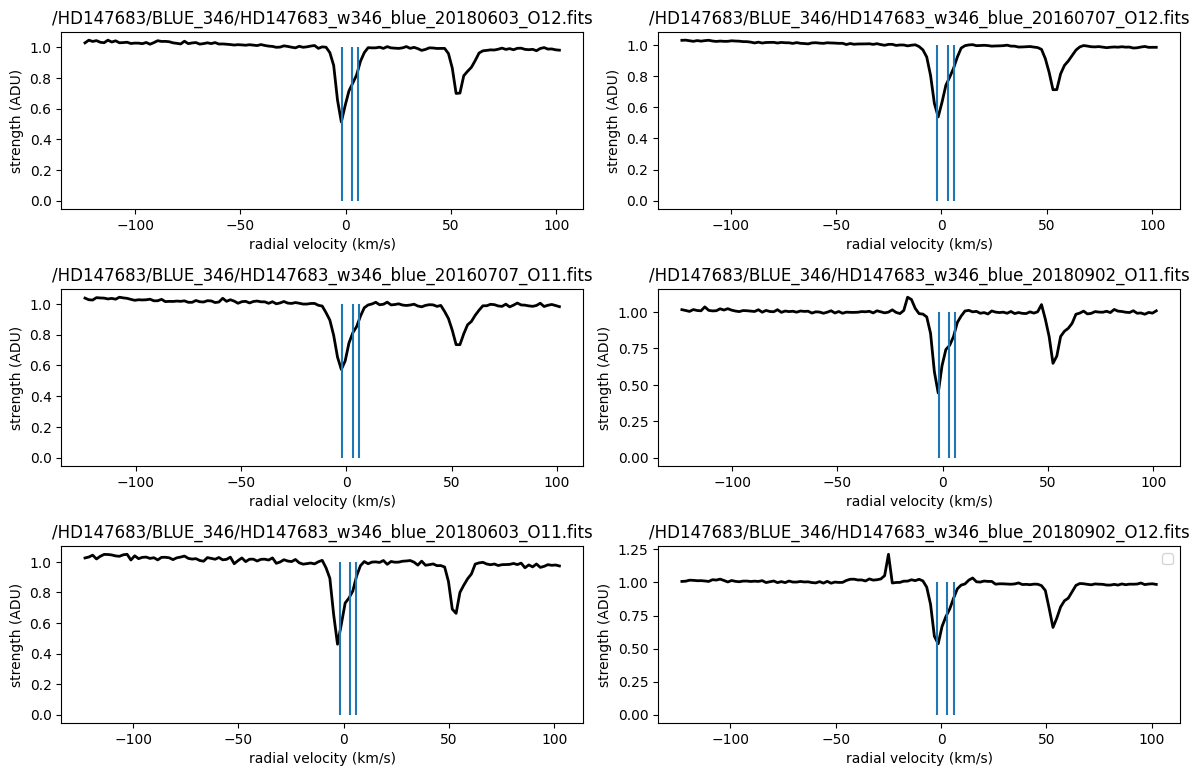

/HD147683/BLUE_346/HD147683_w346_blue_20180603_O12.fits
/HD147683/BLUE_346/HD147683_w346_blue_20160707_O12.fits
/HD147683/BLUE_346/HD147683_w346_blue_20160707_O11.fits
/HD147683/BLUE_346/HD147683_w346_blue_20180902_O11.fits
/HD147683/BLUE_346/HD147683_w346_blue_20180603_O11.fits
/HD147683/BLUE_346/HD147683_w346_blue_20180902_O12.fits


In [67]:
sightline = "HD 147683"
pythia = EdiblesOracle()
List_1 = pythia.getFilteredObsList(object=[sightline], MergedOnly=False, Wave=3302)
test_1 = List_1.values.tolist()
List_2 = pythia.getFilteredObsList(object=[sightline], MergedOnly=True, Wave=3302)
test_2 = List_2.values.tolist()
test = set(test_1) - set(test_2)
test = list(test)
# print(test)

# filename = test[6]

lambda0 = [3302.368, 3302.978]
ref_wave = 3302.368
cl_1 = -2
cl_2 = 3
cl_3 = 6
# cl_4 = -36
# cl_5 = -7
# f = [0.005450, 0.005450]
# gamma = [1e8,1e8]
# b = [3.5, 3.5]
# N = [5e13/50, 5e13]
# map = [0, 1]
# v_rad = 20
# v_resolution = 3
# B_vary = [0]

l = len(test)
rows = l//2 + 1

# Create a figure and an array of subplots (3x3 grid)
fig, axs = plt.subplots(rows, 2, figsize=(12,10))#(12, 15))

# Flatten the 2D array of axes to easily index them in a single loop
axs = axs.flatten()

for i in range(len(test)):
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    # Define the wavelength range and fetch the spectrum
    wrange = [3301, 3303.5]
    sp = EdiblesSpectrum(test[i])
    sp.getSpectrum(xmin=wrange[0], xmax=wrange[1])
    wave = sp.bary_wave
    flux = sp.bary_flux

    # Filter the spectrum within the specified wavelength range
    idx = np.where((wave > wrange[0]) & (wave < wrange[1]))
    wave = wave[idx]
    flux = flux[idx]

    # Normalize the flux
    flux = flux / np.median(flux)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # Plot data on the corresponding subplot
    axs[i].plot(3*(10**5)*(wave-ref_wave)/ref_wave, flux, color='k', linewidth=2)
    axs[i].vlines(x=cl_1, ymin=0, ymax=1)
    axs[i].vlines(x=cl_2, ymin=0, ymax=1)
    axs[i].vlines(x=cl_3, ymin=0, ymax=1)
    # axs[i].vlines(x=cl_4, ymin=0, ymax=1)
    # axs[i].vlines(x=cl_5, ymin=0, ymax=1)

    # y = np.ones(len(wave))
    # axs[i].plot(wave, y)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # model = voigt_absorption_line_new(wavegrid=wave, f= f, lambda0=lambda0, gamma=gamma, 
    #                    b=b, B_vary=B_vary, N=N, v_rad=v_rad, v_resolution=v_resolution, map =[0,1])
    
    # axs[i].plot(wave, model)

    # Set title for each subplot
    axs[i].set_title(str(test[i]))

    # Set x and y labels for each subplot
    axs[i].set_xlabel('radial velocity (km/s)')
    axs[i].set_ylabel('strength (ADU)')

# Hide the unused subplots
for j in range(len(test), len(axs)):
    fig.delaxes(axs[j])
# Adjust the layout so titles and labels fit well
plt.tight_layout()
plt.legend()
# Show the plot
plt.show()   


for i in test:
    print(i)

# Na II

/Users/ayansahoo/Desktop/MITACS/edibles_spec/DR4
***Common Objects***
['HD 149404']
**Filtered File List**
8950    /HD149404/RED_564/HD149404_w564_redu_20170418_...
8956    /HD149404/RED_564/HD149404_w564_redu_20180630_...
8968    /HD149404/RED_564/HD149404_w564_redu_20170418_...
8979    /HD149404/RED_564/HD149404_w564_redu_20170417_...
8987    /HD149404/RED_564/HD149404_w564_n5_20170418_U....
8990    /HD149404/RED_564/HD149404_w564_redu_20180630_...
9020    /HD149404/RED_564/HD149404_w564_n5_20170507_U....
9024    /HD149404/RED_564/HD149404_w564_n5_20170417_U....
9033    /HD149404/RED_564/HD149404_w564_redu_20180623_...
9037    /HD149404/RED_564/HD149404_w564_n5_20180623_U....
9045    /HD149404/RED_564/HD149404_w564_redu_20170507_...
9060    /HD149404/RED_564/HD149404_w564_redu_20170417_...
9090    /HD149404/RED_564/HD149404_w564_redu_20180623_...
9124    /HD149404/RED_564/HD149404_w564_redu_20170507_...
9140    /HD149404/RED_564/HD149404_w564_n5_20180630_U....
Name: Filename, dtype: 

/var/folders/x3/g_6bp6fj0vx0dk27lr5119r80000gn/T/ipykernel_77513/616700556.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


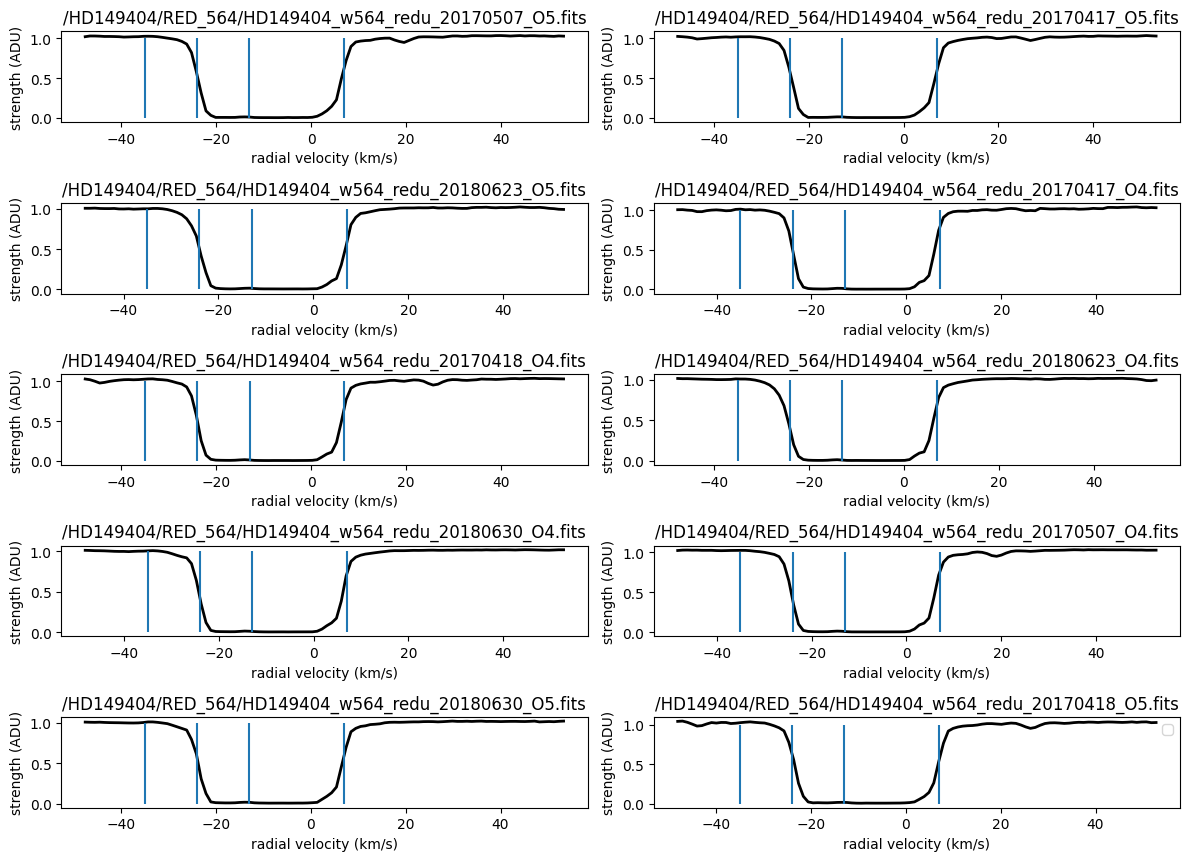

/HD149404/RED_564/HD149404_w564_redu_20170507_O5.fits
/HD149404/RED_564/HD149404_w564_redu_20170417_O5.fits
/HD149404/RED_564/HD149404_w564_redu_20180623_O5.fits
/HD149404/RED_564/HD149404_w564_redu_20170417_O4.fits
/HD149404/RED_564/HD149404_w564_redu_20170418_O4.fits
/HD149404/RED_564/HD149404_w564_redu_20180623_O4.fits
/HD149404/RED_564/HD149404_w564_redu_20180630_O4.fits
/HD149404/RED_564/HD149404_w564_redu_20170507_O4.fits
/HD149404/RED_564/HD149404_w564_redu_20180630_O5.fits
/HD149404/RED_564/HD149404_w564_redu_20170418_O5.fits


In [49]:
sightline = "HD 149404"
pythia = EdiblesOracle()
List_1 = pythia.getFilteredObsList(object=[sightline], MergedOnly=False, Wave=5892)
test_1 = List_1.values.tolist()
List_2 = pythia.getFilteredObsList(object=[sightline], MergedOnly=True, Wave=5892)
test_2 = List_2.values.tolist()
test = set(test_1) - set(test_2)
test = list(test)
# print(test)

# filename = test[6]

lambda0 = [5889.951, 5895.924]
ref_wave = 5889.951
cl_1 = 7
cl_2 = -13
cl_3 = -35
cl_4 = -24
# f = [0.005450, 0.005450]
# gamma = [1e8,1e8]
# b = [3.5, 3.5]
# N = [5e13/50, 5e13]
# map = [0, 1]
# v_rad = 20
# v_resolution = 3
# B_vary = [0]

l = len(test)
rows = l//2 + 1

# Create a figure and an array of subplots (3x3 grid)
fig, axs = plt.subplots(rows, 2, figsize=(12,10))#(12, 15))

# Flatten the 2D array of axes to easily index them in a single loop
axs = axs.flatten()

for i in range(len(test)):
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    # Define the wavelength range and fetch the spectrum
    wrange = [5889, 5891]
    sp = EdiblesSpectrum(test[i])
    sp.getSpectrum(xmin=wrange[0], xmax=wrange[1])
    wave = sp.bary_wave
    flux = sp.bary_flux

    # Filter the spectrum within the specified wavelength range
    idx = np.where((wave > wrange[0]) & (wave < wrange[1]))
    wave = wave[idx]
    flux = flux[idx]

    # Normalize the flux
    flux = flux / np.median(flux)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # Plot data on the corresponding subplot
    axs[i].plot(3*(10**5)*(wave-ref_wave)/ref_wave, flux, color='k', linewidth=2)
    axs[i].vlines(x=cl_1, ymin=0, ymax=1)
    axs[i].vlines(x=cl_2, ymin=0, ymax=1)
    axs[i].vlines(x=cl_3, ymin=0, ymax=1)
    axs[i].vlines(x=cl_4, ymin=0, ymax=1)

    # y = np.ones(len(wave))
    # axs[i].plot(wave, y)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # model = voigt_absorption_line_new(wavegrid=wave, f= f, lambda0=lambda0, gamma=gamma, 
    #                    b=b, B_vary=B_vary, N=N, v_rad=v_rad, v_resolution=v_resolution, map =[0,1])
    
    # axs[i].plot(wave, model)

    # Set title for each subplot
    axs[i].set_title(str(test[i]))

    # Set x and y labels for each subplot
    axs[i].set_xlabel('radial velocity (km/s)')
    axs[i].set_ylabel('strength (ADU)')

# Hide the unused subplots
for j in range(len(test), len(axs)):
    fig.delaxes(axs[j])
# Adjust the layout so titles and labels fit well
plt.tight_layout()
plt.legend()
# Show the plot
plt.show()   


for i in test:
    print(i)

# K

/Users/ayansahoo/Desktop/MITACS/edibles_spec/DR4
***Common Objects***
['HD 149404']
**Filtered File List**
9328    /HD149404/RED_860/HD149404_w860_redl_20170507_...
9340    /HD149404/RED_860/HD149404_w860_n12_20170507_L...
9351    /HD149404/RED_860/HD149404_w860_redl_20180630_...
9361    /HD149404/RED_860/HD149404_w860_redl_20170507_...
9369    /HD149404/RED_860/HD149404_w860_n12_20180630_L...
9371    /HD149404/RED_860/HD149404_w860_redl_20180630_...
Name: Filename, dtype: object
6
***Common Objects***
['HD 149404']
**Filtered File List**
9340    /HD149404/RED_860/HD149404_w860_n12_20170507_L...
9369    /HD149404/RED_860/HD149404_w860_n12_20180630_L...
Name: Filename, dtype: object
2


/var/folders/x3/g_6bp6fj0vx0dk27lr5119r80000gn/T/ipykernel_77513/2510467989.py:87: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


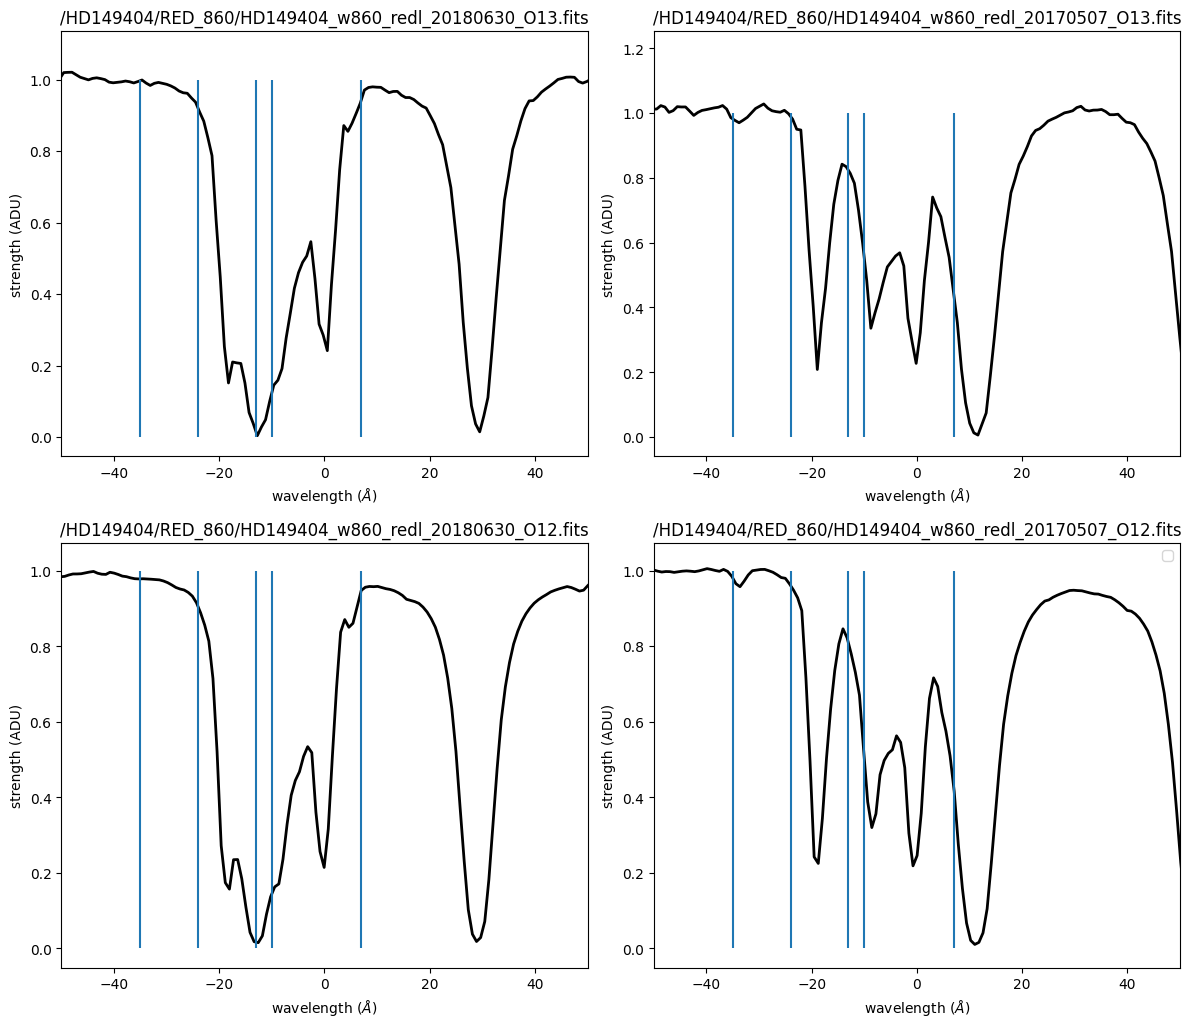

/HD149404/RED_860/HD149404_w860_redl_20180630_O13.fits
/HD149404/RED_860/HD149404_w860_redl_20170507_O13.fits
/HD149404/RED_860/HD149404_w860_redl_20180630_O12.fits
/HD149404/RED_860/HD149404_w860_redl_20170507_O12.fits


In [50]:
sightline = "HD 149404"
pythia = EdiblesOracle()
List_1 = pythia.getFilteredObsList(object=[sightline], MergedOnly=False, Wave=7665)
test_1 = List_1.values.tolist()
List_2 = pythia.getFilteredObsList(object=[sightline], MergedOnly=True, Wave=7665)
test_2 = List_2.values.tolist()
test = set(test_1) - set(test_2)
test = list(test)
# print(test)

# filename = test[6]

lambda0 = [7664.899]
ref_wave = 7664.899
cl_1 = 7
cl_2 = -13
cl_3 = -35
cl_4 = -24
cl_5 = -10
# f = [0.005450, 0.005450]
# gamma = [1e8,1e8]
# b = [3.5, 3.5]
# N = [5e13/50, 5e13]
# map = [0, 1]
# v_rad = 20
# v_resolution = 3
# B_vary = [0]

l = len(test)
rows = l//2 + 1

# Create a figure and an array of subplots (3x3 grid)
fig, axs = plt.subplots(rows, 2, figsize=(12, 15))

# Flatten the 2D array of axes to easily index them in a single loop
axs = axs.flatten()

for i in range(len(test)):
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    # Define the wavelength range and fetch the spectrum
    wrange = [7661, 7670]
    
    sp = EdiblesSpectrum(test[i])
    sp.getSpectrum(xmin=wrange[0], xmax=wrange[1])
    wave = sp.bary_wave
    flux = sp.bary_flux

    # Filter the spectrum within the specified wavelength range
    idx = np.where((wave > wrange[0]) & (wave < wrange[1]))
    wave = wave[idx]
    flux = flux[idx]

    # Normalize the flux
    flux = flux / np.median(flux)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # Plot data on the corresponding subplot
    axs[i].plot(3*(10**5)*(wave-ref_wave)/ref_wave, flux, color='k', linewidth=2)
    axs[i].vlines(x=cl_1, ymin=0, ymax=1)
    axs[i].vlines(x=cl_2, ymin=0, ymax=1)
    axs[i].vlines(x=cl_3, ymin=0, ymax=1)
    axs[i].vlines(x=cl_4, ymin=0, ymax=1)
    axs[i].vlines(x=cl_5, ymin=0, ymax=1)
    # y = np.ones(len(wave))
    # axs[i].plot(wave, y)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # model = voigt_absorption_line_new(wavegrid=wave, f= f, lambda0=lambda0, gamma=gamma, 
    #                    b=b, B_vary=B_vary, N=N, v_rad=v_rad, v_resolution=v_resolution, map =[0,1])
    
    # axs[i].plot(wave, model)

    # Set title for each subplot
    axs[i].set_title(str(test[i]))

    # Set x and y labels for each subplot
    axs[i].set_xlabel('wavelength ($\AA$)')
    axs[i].set_ylabel('strength (ADU)')

    axs[i].set_xlim(-50, 50)

# Hide the unused subplots
for j in range(len(test), len(axs)):
    fig.delaxes(axs[j])
# Adjust the layout so titles and labels fit well
plt.tight_layout()
plt.legend()
# Show the plot
plt.show()   


for i in test:
    print(i)

/Users/ayansahoo/Desktop/MITACS/edibles_spec/DR4
***Common Objects***
['HD 147683']
**Filtered File List**
15746    /HD147683/RED_860/HD147683_w860_redl_20180902_...
15751    /HD147683/RED_860/HD147683_w860_n10_20180902_L...
Name: Filename, dtype: object
2
***Common Objects***
['HD 147683']
**Filtered File List**
15751    /HD147683/RED_860/HD147683_w860_n10_20180902_L...
Name: Filename, dtype: object
1


/var/folders/x3/g_6bp6fj0vx0dk27lr5119r80000gn/T/ipykernel_77513/3053392824.py:87: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


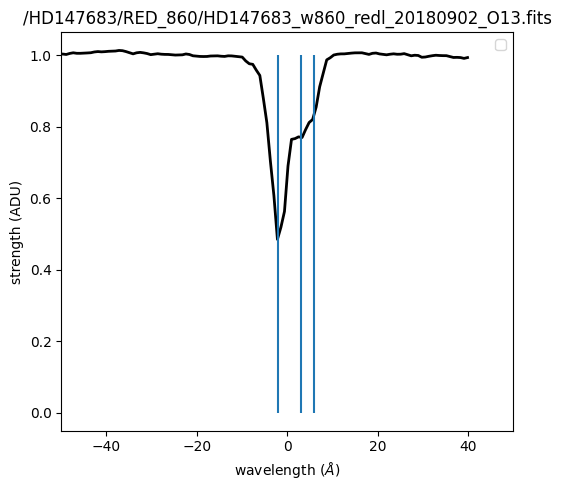

/HD147683/RED_860/HD147683_w860_redl_20180902_O13.fits


In [66]:
sightline = "HD 147683"
pythia = EdiblesOracle()
List_1 = pythia.getFilteredObsList(object=[sightline], MergedOnly=False, Wave=7698)
test_1 = List_1.values.tolist()
List_2 = pythia.getFilteredObsList(object=[sightline], MergedOnly=True, Wave=7698)
test_2 = List_2.values.tolist()
test = set(test_1) - set(test_2)
test = list(test)
# print(test)

# filename = test[6]

lambda0 = [7698.965]
ref_wave = 7698.965
cl_1 = -2
cl_2 = 3
cl_3 = 6
# cl_4 = -36
# cl_5 = -10
# f = [0.005450, 0.005450]
# gamma = [1e8,1e8]
# b = [3.5, 3.5]
# N = [5e13/50, 5e13]
# map = [0, 1]
# v_rad = 20
# v_resolution = 3
# B_vary = [0]

l = len(test)
rows = l//2 + 1

# Create a figure and an array of subplots (3x3 grid)
fig, axs = plt.subplots(rows, 2, figsize=(10, 5))

# Flatten the 2D array of axes to easily index them in a single loop
axs = axs.flatten()

for i in range(len(test)):
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    # Define the wavelength range and fetch the spectrum
    wrange = [7697, 7700]
    
    sp = EdiblesSpectrum(test[i])
    sp.getSpectrum(xmin=wrange[0], xmax=wrange[1])
    wave = sp.bary_wave
    flux = sp.bary_flux

    # Filter the spectrum within the specified wavelength range
    idx = np.where((wave > wrange[0]) & (wave < wrange[1]))
    wave = wave[idx]
    flux = flux[idx]

    # Normalize the flux
    flux = flux / np.median(flux)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # Plot data on the corresponding subplot
    axs[i].plot(3*(10**5)*(wave-ref_wave)/ref_wave, flux, color='k', linewidth=2)
    axs[i].vlines(x=cl_1, ymin=0, ymax=1)
    axs[i].vlines(x=cl_2, ymin=0, ymax=1)
    axs[i].vlines(x=cl_3, ymin=0, ymax=1)
    # axs[i].vlines(x=cl_4, ymin=0, ymax=1)
    # axs[i].vlines(x=cl_5, ymin=0.9, ymax=1)
    # y = np.ones(len(wave))
    # axs[i].plot(wave, y)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # model = voigt_absorption_line_new(wavegrid=wave, f= f, lambda0=lambda0, gamma=gamma, 
    #                    b=b, B_vary=B_vary, N=N, v_rad=v_rad, v_resolution=v_resolution, map =[0,1])
    
    # axs[i].plot(wave, model)

    # Set title for each subplot
    axs[i].set_title(str(test[i]))

    # Set x and y labels for each subplot
    axs[i].set_xlabel('wavelength ($\AA$)')
    axs[i].set_ylabel('strength (ADU)')

    axs[i].set_xlim(-50, 50)

# Hide the unused subplots
for j in range(len(test), len(axs)):
    fig.delaxes(axs[j])
# Adjust the layout so titles and labels fit well
plt.tight_layout()
plt.legend()
# Show the plot
plt.show()   


for i in test:
    print(i)